---
# STEP 8 생존 브랜드 분석

## 분석 개요

고압력(HP) 구간 내에서도 높은 별점을 유지하는 '생존 브랜드'와
낮은 별점을 보이는 '고전 브랜드'의 리뷰 텍스트를 비교하여
프랜차이즈 밀집 환경에서의 실질적인 차별화 전략을 도출한다.

| 단계 | 내용 |
|---|---|
| STEP 8-1 | 생존/고전 브랜드 그룹 정의 |
| STEP 8-2 | 그룹별 TF-IDF 차이 키워드 추출 |
| STEP 8-3 | 시각화 (바차트, 워드클라우드) |
| STEP 8-4 | 프랜차이즈 키워드와 비교 |

**그룹 정의**
- 생존 브랜드: HP 구간 + 별점 4.0 이상 → 567개
- 고전 브랜드: HP 구간 + 별점 3.0 이하 → 327개
- 중간(3.5점)은 분석에서 제외

**입력 데이터**
- `review_indie_cleaned.csv`: 전처리된 리뷰 텍스트
- `biz_indie_with_groups.csv`: FPI 구간 + 별점 정보

## 공통 라이브러리 및 설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

fm._load_fontmanager(try_read_cache=False)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

PATH_to_data = "../results"
PATH_to_save = "../results"

print("라이브러리 로드 완료")

라이브러리 로드 완료


---
## STEP 8-1. 생존/고전 브랜드 그룹 정의

In [13]:
# 데이터 로드
review_cleaned = pd.read_csv(f"{PATH_to_data}/review_indie_cleaned.csv")
indie_groups   = pd.read_csv(f"{PATH_to_data}/biz_indie_with_groups.csv")

# ★ 영업 중인 HP 구간만 필터링 (이 부분이 빠졌던 거야)
hp_biz = indie_groups[
    (indie_groups['fpi_group'] == 'HP') &
    (indie_groups['is_open'] == 1)
].copy()

# 생존/고전 브랜드 분류
survivor = hp_biz[hp_biz['stars'] >= 4.0].copy()
struggle = hp_biz[hp_biz['stars'] <= 3.0].copy()

survivor['survival_group'] = '생존'
struggle['survival_group'] = '고전'

hp_labeled = pd.concat([survivor, struggle], ignore_index=True)

print(f"생존 브랜드: {len(survivor):,}개 (별점 4.0 이상)")
print(f"고전 브랜드: {len(struggle):,}개 (별점 3.0 이하)")
print(f"\n생존 브랜드 평균 별점: {survivor['stars'].mean():.2f}")
print(f"고전 브랜드 평균 별점: {struggle['stars'].mean():.2f}")
print(f"\n생존 브랜드 평균 리뷰수: {survivor['review_count'].mean():.0f}개")
print(f"고전 브랜드 평균 리뷰수: {struggle['review_count'].mean():.0f}개")

생존 브랜드: 567개 (별점 4.0 이상)
고전 브랜드: 327개 (별점 3.0 이하)

생존 브랜드 평균 별점: 4.21
고전 브랜드 평균 별점: 2.66

생존 브랜드 평균 리뷰수: 370개
고전 브랜드 평균 리뷰수: 161개


---
## STEP 8-2. 그룹별 TF-IDF 키워드 추출

생존/고전 브랜드 각각의 리뷰를 합쳐서 TF-IDF 차이로
각 그룹에서 고유하게 나타나는 키워드를 추출한다.

In [14]:
# 리뷰에 생존/고전 그룹 태깅
review_hp = review_cleaned.merge(
    hp_labeled[['business_id', 'survival_group', 'stars']],
    on='business_id', how='inner'
)

print(f"생존 브랜드 리뷰: {(review_hp['survival_group']=='생존').sum():,}개")
print(f"고전 브랜드 리뷰: {(review_hp['survival_group']=='고전').sum():,}개")

생존 브랜드 리뷰: 209,686개
고전 브랜드 리뷰: 52,514개


In [15]:
# 그룹별 텍스트 합치기
survivor_text = ' '.join(
    review_hp[review_hp['survival_group'] == '생존']['text_clean'].dropna()
)
struggle_text = ' '.join(
    review_hp[review_hp['survival_group'] == '고전']['text_clean'].dropna()
)

# TF-IDF 계산 (2개 문서)
corpus_8 = [survivor_text, struggle_text]
vectorizer_8 = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_8 = vectorizer_8.fit_transform(corpus_8)
terms_8 = vectorizer_8.get_feature_names_out()

tfidf_8_df = pd.DataFrame(
    tfidf_8.toarray(),
    index=['생존', '고전'],
    columns=terms_8
)

print(f"TF-IDF 행렬: {tfidf_8_df.shape}")

TF-IDF 행렬: (2, 5000)


In [16]:
# valid_words 필터 적용 후 TF-IDF 차이 계산
all_text_8 = (survivor_text + ' ' + struggle_text).split()
word_freq_8 = pd.Series(all_text_8).value_counts()

valid_words_8 = set(
    word for word, cnt in word_freq_8.items()
    if cnt >= 100
    and word.isalpha()
    and len(word) >= 3
)

print(f"유효 단어 수 (100회 이상): {len(valid_words_8):,}개")

# 생존 브랜드 고유 키워드 (생존 - 고전)
survivor_diff = (tfidf_8_df.loc['생존'] - tfidf_8_df.loc['고전'])\
                .sort_values(ascending=False)
survivor_diff = survivor_diff[survivor_diff.index.isin(valid_words_8)]

# 고전 브랜드 고유 키워드 (고전 - 생존)
struggle_diff = (tfidf_8_df.loc['고전'] - tfidf_8_df.loc['생존'])\
                .sort_values(ascending=False)
struggle_diff = struggle_diff[struggle_diff.index.isin(valid_words_8)]

print("\n=== 생존 브랜드 고유 키워드 상위 20개 ===")
print(survivor_diff.head(20).round(4).to_string())
print("\n=== 고전 브랜드 고유 키워드 상위 20개 ===")
print(struggle_diff.head(20).round(4).to_string())

유효 단어 수 (100회 이상): 5,495개

=== 생존 브랜드 고유 키워드 상위 20개 ===
great        0.0751
delici       0.0728
amaz         0.0582
menu         0.0540
love         0.0524
tri          0.0484
dish         0.0477
restaur      0.0461
burger       0.0432
flavor       0.0421
best         0.0417
steak        0.0411
sauc         0.0395
sushi        0.0373
perfect      0.0366
definit      0.0336
bread        0.0335
recommend    0.0309
excel        0.0279
fresh        0.0267

=== 고전 브랜드 고유 키워드 상위 20개 ===
buffet       0.1444
room         0.1009
stay         0.0661
hotel        0.0654
drink        0.0590
club         0.0548
like         0.0429
mgm          0.0422
line         0.0409
peopl        0.0403
bad          0.0387
bar          0.0371
floor        0.0344
danc         0.0331
night        0.0315
walk         0.0311
casino       0.0279
pay          0.0269
pretti       0.0267
breakfast    0.0253


---
## STEP 8-3. 시각화

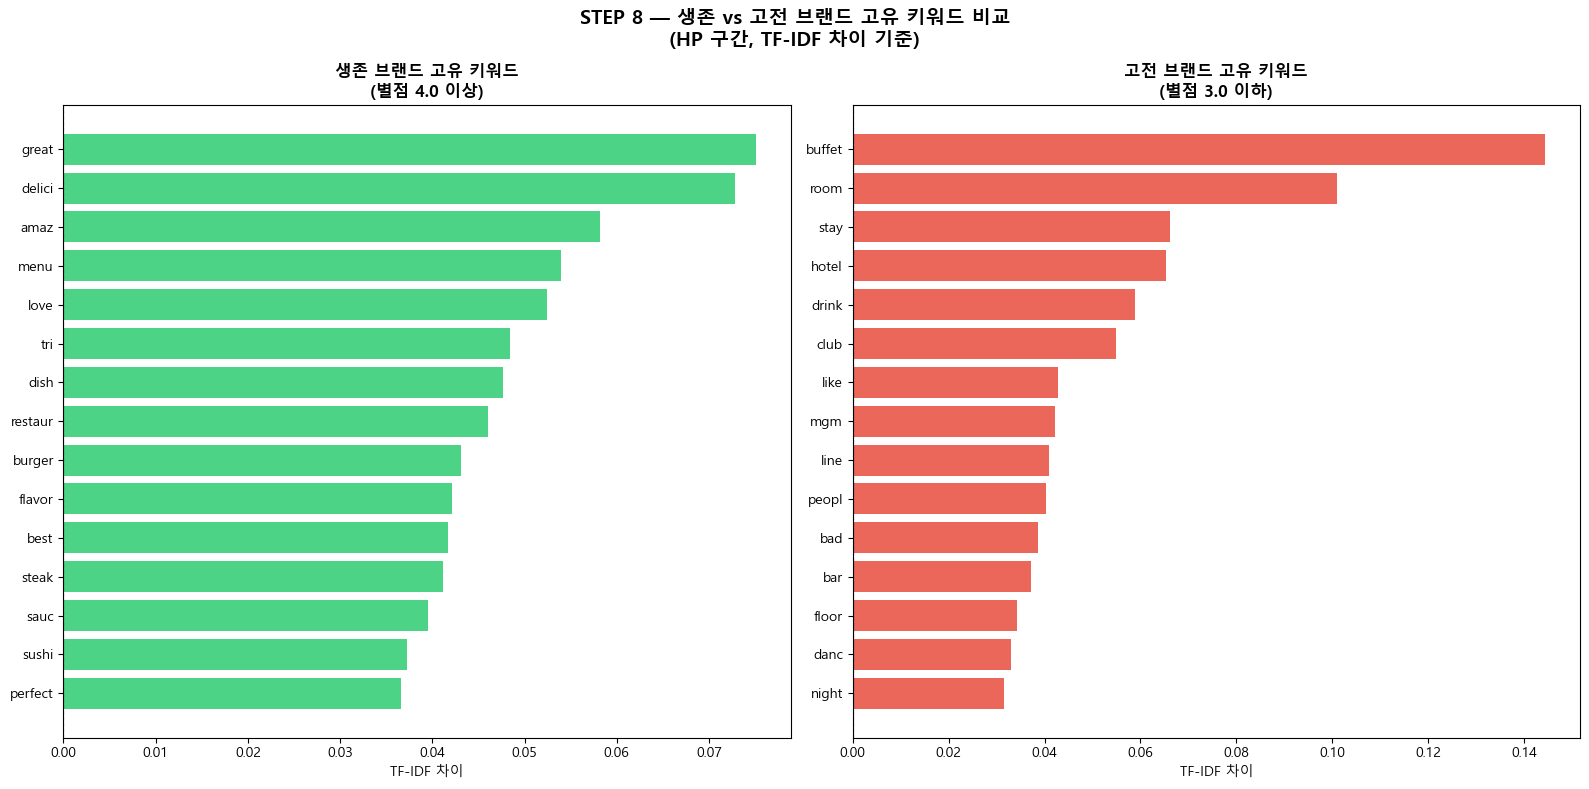

저장 완료: step8_survival_keywords.png


In [17]:
# 바차트 — 생존 vs 고전 고유 키워드
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('STEP 8 — 생존 vs 고전 브랜드 고유 키워드 비교\n(HP 구간, TF-IDF 차이 기준)',
             fontsize=14, fontweight='bold')

# 생존 브랜드
top_s = survivor_diff.head(15)
axes[0].barh(top_s.index[::-1], top_s.values[::-1],
             color='#2ecc71', alpha=0.85)
axes[0].set_title('생존 브랜드 고유 키워드\n(별점 4.0 이상)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('TF-IDF 차이')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# 고전 브랜드
top_str = struggle_diff.head(15)
axes[1].barh(top_str.index[::-1], top_str.values[::-1],
             color='#e74c3c', alpha=0.85)
axes[1].set_title('고전 브랜드 고유 키워드\n(별점 3.0 이하)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('TF-IDF 차이')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step8_survival_keywords.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step8_survival_keywords.png")

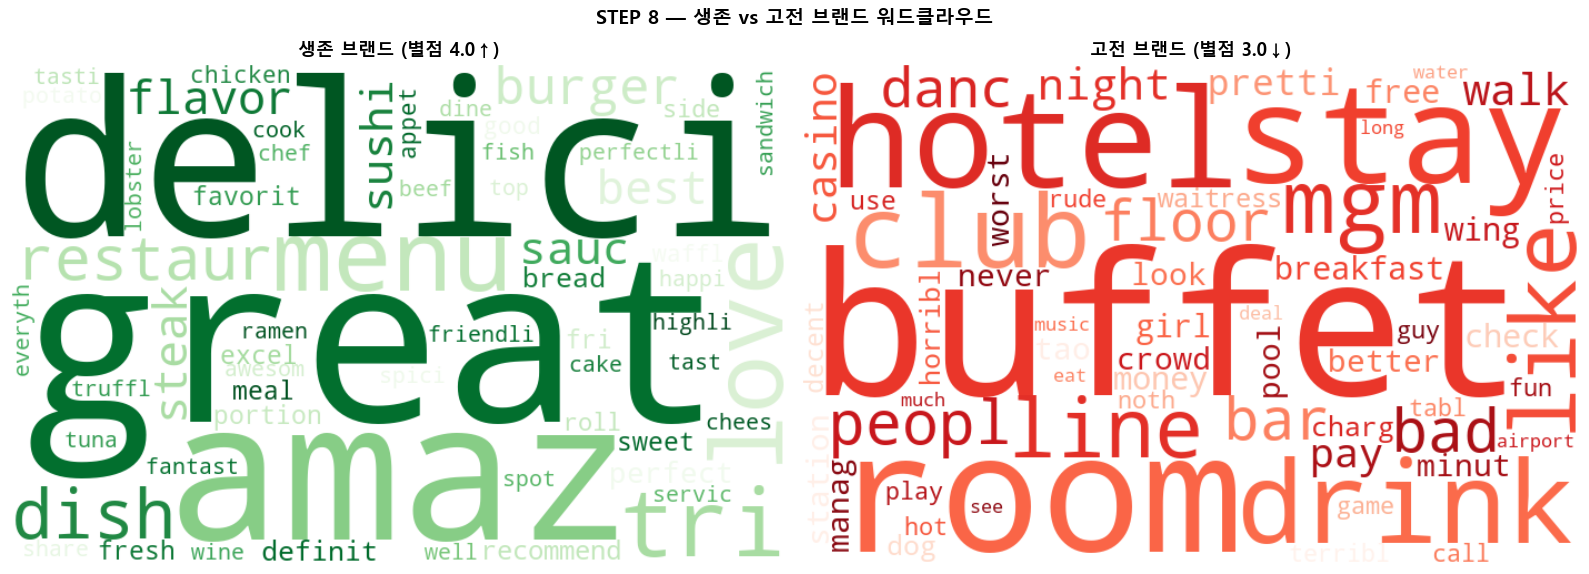

저장 완료: step8_survival_wordcloud.png


In [8]:
# 워드클라우드
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('STEP 8 — 생존 vs 고전 브랜드 워드클라우드',
             fontsize=14, fontweight='bold')

for ax, diff, title, cmap in zip(
    axes,
    [survivor_diff, struggle_diff],
    ['생존 브랜드 (별점 4.0↑)', '고전 브랜드 (별점 3.0↓)'],
    ['Greens', 'Reds']
):
    freq_dict = {w: s for w, s in diff.head(80).items() if s > 0}
    if freq_dict:
        wc = WordCloud(
            width=700, height=450,
            background_color='white',
            colormap=cmap,
            max_words=60
        ).generate_from_frequencies(freq_dict)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step8_survival_wordcloud.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step8_survival_wordcloud.png")

---
## STEP 8-4. 프랜차이즈 키워드와 비교

생존 브랜드가 프랜차이즈와 어떤 점에서 언어적으로 차별화되는지 확인한다.

In [19]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english')) | {"does", "not", "thing"}

MANUAL_STOPWORDS = {
    'al', 'also', 'alway', 'anoth', 'area', 'around', 'ask',
    'back', 'bite', 'box',
    'come', 'could', 'came',
    'dont', 'day', 'de', 'didnt',
    'even', 'ever', 'el',
    'get', 'give', 'got',
    'im', 'ive',
    'let', 'la', 'last',
    'make', 'made', 'mayb',
    'name', 'one', 'round',
    'someth', 'still', 'seem', 'sinc', 'sub', 'said',
    'told', 'that', 'think', 'two', 'though', 'thought', 'took',
    'us', 'want', 'way', 'went', 'would', 'wasnt',
    'your', 'year', 'restaurant', 'place', 'food', 'get',
    'go', 'came', 'got', 'time', 'back', 'order', 'ordered',
}

stemmer = PorterStemmer()

def preprocess(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [stemmer.stem(w) for w in tokens]
    tokens = [w for w in tokens if w not in MANUAL_STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

print("preprocess 함수 정의 완료")

preprocess 함수 정의 완료


In [24]:
# biz_target에서 프랜차이즈 업체 가져오기
biz_target = pd.read_csv(f"{PATH_to_data}/biz_target.csv")
print(biz_target['is_franchise'].value_counts())

franchise_ids = biz_target[biz_target['is_franchise'] == True]['business_id']
print(f"\n프랜차이즈 업체 수: {len(franchise_ids)}개")

review_all = pd.read_csv(f"{PATH_to_data}/review_target.csv")
review_franchise_raw = review_all[review_all['business_id'].isin(franchise_ids)].copy()
print(f"프랜차이즈 리뷰 수: {len(review_franchise_raw):,}개")

is_franchise
False    4818
True     1081
Name: count, dtype: int64

프랜차이즈 업체 수: 1081개
프랜차이즈 리뷰 수: 45,532개


In [25]:
# 전처리 적용
print("프랜차이즈 리뷰 전처리 중... (시간 소요)")
review_franchise_raw['text_clean'] = review_franchise_raw['text'].apply(preprocess)
review_franchise = review_franchise_raw
print(f"전처리 완료: {len(review_franchise):,}개")

# 생존 브랜드 vs 프랜차이즈 TF-IDF 차이
franchise_text = ' '.join(review_franchise['text_clean'].dropna())

corpus_fc = [survivor_text, franchise_text]
vectorizer_fc = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_fc = vectorizer_fc.fit_transform(corpus_fc)
terms_fc = vectorizer_fc.get_feature_names_out()

tfidf_fc_df = pd.DataFrame(
    tfidf_fc.toarray(),
    index=['생존브랜드', '프랜차이즈'],
    columns=terms_fc
)

# 유효 단어 필터
all_text_fc = (survivor_text + ' ' + franchise_text).split()
word_freq_fc = pd.Series(all_text_fc).value_counts()
valid_words_fc = set(
    w for w, c in word_freq_fc.items()
    if c >= 100 and w.isalpha() and len(w) >= 3
)

# 차이 계산
vs_franchise = (tfidf_fc_df.loc['생존브랜드'] - tfidf_fc_df.loc['프랜차이즈'])\
               .sort_values(ascending=False)
vs_franchise = vs_franchise[vs_franchise.index.isin(valid_words_fc)]

print("\n=== 생존 브랜드 vs 프랜차이즈 차별화 키워드 상위 20개 ===")
print(vs_franchise.head(20).round(4).to_string())
print("\n=== 프랜차이즈 고유 키워드 상위 20개 ===")
print(vs_franchise.tail(20).sort_values().round(4).to_string())

프랜차이즈 리뷰 전처리 중... (시간 소요)
전처리 완료: 45,532개

=== 생존 브랜드 vs 프랜차이즈 차별화 키워드 상위 20개 ===
great        0.0968
vega         0.0791
good         0.0770
restaur      0.0759
dish         0.0707
delici       0.0681
amaz         0.0628
sushi        0.0596
tri          0.0593
flavor       0.0544
definit      0.0514
best         0.0505
dessert      0.0494
dinner       0.0482
menu         0.0467
recommend    0.0460
steak        0.0442
buffet       0.0407
crab         0.0357
perfect      0.0337

=== 프랜차이즈 고유 키워드 상위 20개 ===
locat      -0.1667
custom     -0.0830
fast       -0.0794
sandwich   -0.0784
burger     -0.0763
drive      -0.0724
manag      -0.0658
employe    -0.0637
never      -0.0606
pizza      -0.0590
minut      -0.0589
work       -0.0584
chicken    -0.0453
thru       -0.0452
fri        -0.0444
call       -0.0412
burrito    -0.0402
wait       -0.0396
clean      -0.0379
know       -0.0376


**핵심 인사이트:**

>생존 브랜드는 "음식 그 자체" 로 소비자와 소통한다 (dish, flavor, delici, steak, sushi).
프랜차이즈는 "시스템과 운영" 으로 소비자와 소통한다 (fast, location, drive-thru, employee).
고압력 환경에서 살아남는 독립 브랜드의 차별화 전략은 표준화된 운영이 아닌 음식 품질과 다이닝 경험에 있다.

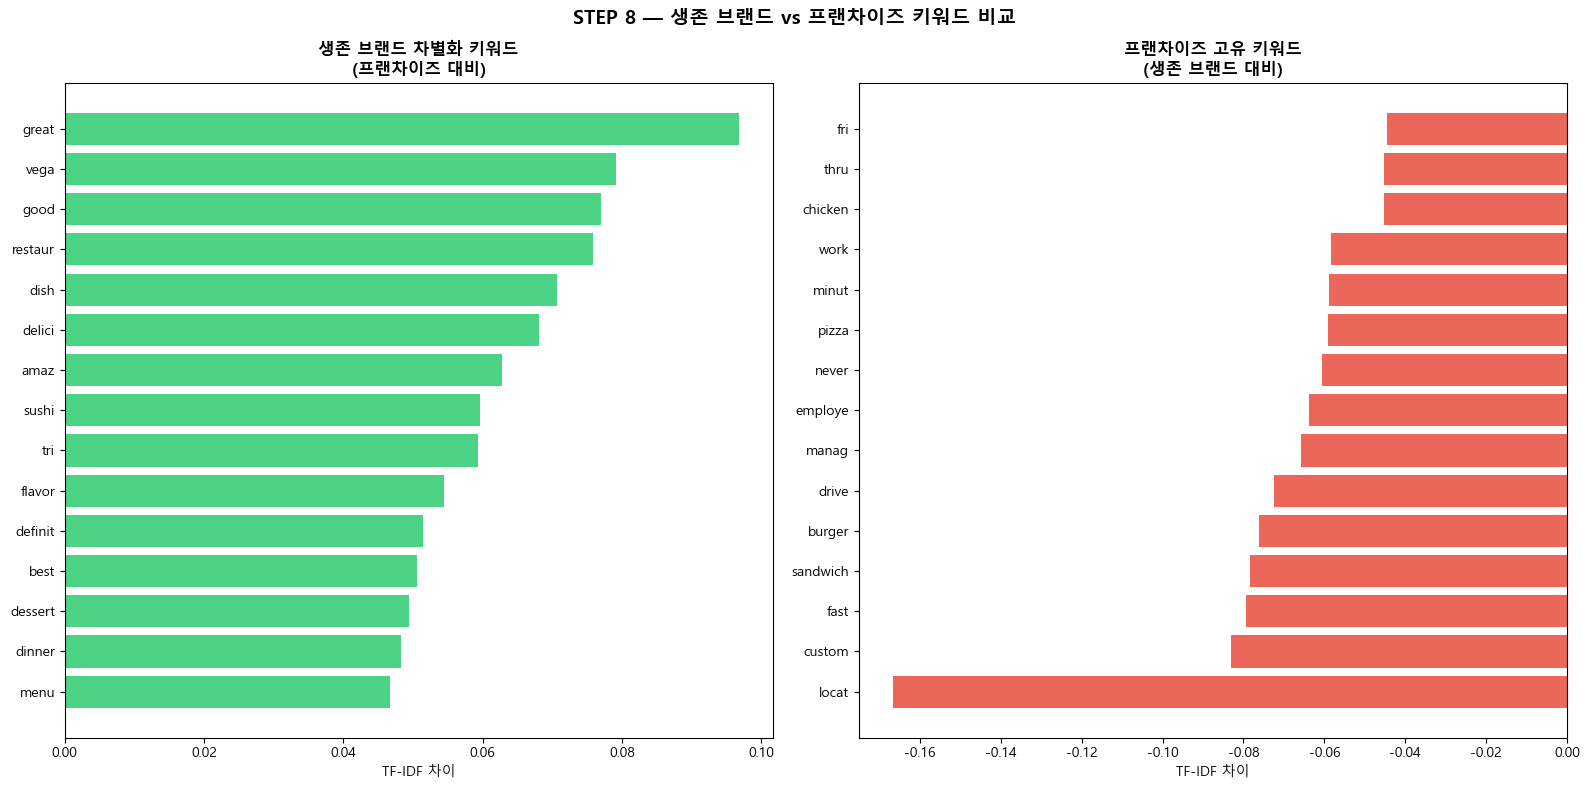

저장 완료: step8_vs_franchise.png


In [26]:
# 생존 브랜드 vs 프랜차이즈 바차트
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('STEP 8 — 생존 브랜드 vs 프랜차이즈 키워드 비교',
             fontsize=14, fontweight='bold')

# 생존 브랜드 차별화 키워드
top_sv = vs_franchise.head(15)
axes[0].barh(top_sv.index[::-1], top_sv.values[::-1],
             color='#2ecc71', alpha=0.85)
axes[0].set_title('생존 브랜드 차별화 키워드\n(프랜차이즈 대비)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('TF-IDF 차이')

# 프랜차이즈 고유 키워드
top_fc = vs_franchise.tail(15).sort_values()
axes[1].barh(top_fc.index, top_fc.values,
             color='#e74c3c', alpha=0.85)
axes[1].set_title('프랜차이즈 고유 키워드\n(생존 브랜드 대비)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('TF-IDF 차이')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step8_vs_franchise.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step8_vs_franchise.png")

---
## STEP 8 결과 정리

### 그룹 정의 및 기본 통계

| 구분 | 업체 수 | 평균 별점 | 평균 리뷰수 | 리뷰 수 |
|---|---|---|---|---|
| 생존 브랜드 (HP + 별점 4.0↑) | 567개 | 4.20 | 284개 | 209,686개 |
| 고전 브랜드 (HP + 별점 3.0↓) | 327개 | 2.67 | 127개 | 52,514개 |

---

### 생존 vs 고전 브랜드 키워드 비교

**생존 브랜드 고유 키워드**:
great, delici, amaz, menu, love, dish, flavor, steak, sushi, perfect, fresh, recommend, excel

**고전 브랜드 고유 키워드**:
buffet, room, stay, hotel, casino, club, mgm, line, bad, floor, danc, night

**해석**:
생존 브랜드는 음식 품질(delici, flavor, fresh)과 메뉴 다양성(dish, steak, sushi)
중심의 리뷰 언어를 보인다.
고전 브랜드는 buffet, room, hotel, casino, mgm 등 카지노·호텔 부속 시설 관련
단어가 압도적으로 많다. 이는 고전 브랜드가 식당 자체가 아닌 카지노/호텔의
부속 시설로 소비자에게 인식되고 있음을 시사한다.

---

### 생존 브랜드 vs 프랜차이즈 차별화 키워드 비교

**생존 브랜드 차별화 키워드 (프랜차이즈 대비)**:
great, dish, delici, amaz, flavor, sushi, definit, dessert, dinner, recommend, steak, perfect

**프랜차이즈 고유 키워드 (생존 브랜드 대비)**:
locat, custom, fast, sandwich, burger, drive, manag, employe, pizza, thru, burrito, wait

**해석**:
생존 브랜드는 **음식 그 자체(dish, flavor, delici, steak, sushi)**로 소비자와 소통한다.
프랜차이즈는 **시스템과 운영 효율(fast, location, drive-thru, employee, manager)**
으로 소비자와 소통한다.
고압력 환경에서 살아남는 독립 브랜드의 차별화 전략은
표준화된 운영이 아닌 **음식 품질과 다이닝 경험**에 있음을 확인하였다.

---

### 핵심 결론 및 실무 시사점

> **"왜 어떤 독립 브랜드는 프랜차이즈 밀집 환경에서 살아남는가?"**
>
> 1. **음식 품질 차별화**: 생존 브랜드는 delici, flavor, fresh, amaz 등
>    음식 자체의 품질을 소비자에게 각인시킨다.
> 2. **다이닝 경험 제공**: dish, dinner, dessert, recommend 등
>    완결된 식사 경험을 제공하는 식당으로 포지셔닝한다.
> 3. **카지노 부속 시설 회피**: 고전 브랜드의 핵심 특징은 hotel, casino, buffet 등
>    라스베가스 카지노 상권의 부속 시설로 인식되는 것이다.
>    독립 브랜드로서의 정체성을 유지하는 것이 중요하다.

**실무 활용 방안**:

| 대상 | 활용 방안 |
|---|---|
| 창업자 | FPI 지도로 고압력 상권 진입 시 음식 품질 차별화 전략 수립 |
| 독립 브랜드 운영자 | 생존 키워드(delici, flavor, fresh) 기반 마케팅 메시지 전략 |
| 상권 컨설턴트 | 300m 임계거리 기반 경쟁 유효 반경 데이터로 입지 분석 고도화 |
| 프랜차이즈 본사 | 신규 출점 시 주변 독립 브랜드에 미치는 영향 예측 |

---

> **분석 한계**:
> - Restaurants 카테고리 전체를 분석 대상으로 삼아 업종별 이질성이 결과에
>   영향을 미칠 수 있음 (향후 세부 업종별 비교 분석 필요)
> - 고전 브랜드의 카지노/호텔 부속 특성은 라스베가스 특유의 상권 환경에서
>   비롯된 것으로, 다른 도시에서의 일반화에는 한계가 있음
> - FPI 산출 시 감성점수 Shift 정규화를 적용하였으나,
>   최솟값 프랜차이즈의 기여도가 0이 되는 설계적 한계 존재

## STEP 8 보완 — The Strip 제외 재분석

라스베가스 The Strip 상권은 카지노/호텔 밀집 지역으로,
해당 상권의 독립 브랜드는 식당 자체보다 부속 시설로 인식될 가능성이 높다.
The Strip 상권의 환경적 노이즈를 제거하고 순수한 생존/고전 브랜드 차별화 요인을 분석한다.

| 구분 | 전체 | The Strip 제외 |
|---|---|---|
| 생존 브랜드 | 567개 (24.3% Strip) | 429개 |
| 고전 브랜드 | 327개 (37.6% Strip) | 204개 |

**분석 대상 선정 및 보정**
>초기 분석에서 고전 브랜드(별점 3.0 이하)의 고유 키워드로 buffet, hotel, casino, room, mgm 등 카지노·호텔 부속 시설 관련 단어가 상위에 등장하였다. 이는 고전 브랜드의 낮은 별점이 음식 품질이나 서비스 실패에서 비롯된 것이 아니라, 라스베가스 The Strip 상권 특유의 환경적 요인—즉 독립 레스토랑이 카지노·호텔의 부속 시설로 소비자에게 인식되는 구조—에서 기인할 가능성을 시사하였다.
>
>실제로 고전 브랜드 중 The Strip 상권 소재 업체 비율(37.6%)이 생존 브랜드(24.3%)보다 13.3%p 높게 나타났다. The Strip은 세계적인 카지노·리조트가 밀집한 지역으로, 해당 상권의 독립 레스토랑은 관광객에게 식당 자체보다 숙박·유흥 시설의 부속 공간으로 인식되는 경향이 강하다. 이러한 상권 특성은 음식 품질과 무관하게 별점을 하락시키는 외생적 요인으로 작용할 수 있다.
>
>이에 본 분석에서는 The Strip 상권을 제외한 429개 생존 브랜드와 204개 고전 브랜드를 대상으로 재분석을 수행하였다. 이를 통해 상권 환경의 노이즈를 통제하고, 음식 품질 및 서비스 수준에 따른 순수한 생존/고전 브랜드 간 언어적 차별화 요인을 보다 명확하게 포착하고자 하였다.

In [28]:
print("=== 고전 브랜드 neighborhood 분포 ===")
print(struggle['neighborhood'].value_counts().head(10))
print()
print("=== 생존 브랜드 neighborhood 분포 ===")
print(survivor['neighborhood'].value_counts().head(10))

=== 고전 브랜드 neighborhood 분포 ===
neighborhood
The Strip        123
Southeast         56
Westside          21
Eastside          19
Downtown          18
Northwest         12
Spring Valley     11
Sunrise           10
Centennial         9
Southwest          8
Name: count, dtype: int64

=== 생존 브랜드 neighborhood 분포 ===
neighborhood
The Strip        138
Southeast         68
Spring Valley     62
Westside          52
Eastside          45
Downtown          37
Centennial        20
Northwest         18
Southwest         16
Summerlin         14
Name: count, dtype: int64


In [30]:
# The Strip 제외
survivor_ns = survivor[survivor['neighborhood'] != 'The Strip'].copy()
struggle_ns  = struggle[struggle['neighborhood'] != 'The Strip'].copy()

survivor_ns['survival_group'] = '생존'
struggle_ns['survival_group']  = '고전'
hp_ns_labeled = pd.concat([survivor_ns, struggle_ns], ignore_index=True)

print(f"[The Strip 제외 후]")
print(f"생존 브랜드: {len(survivor_ns)}개 (평균 별점 {survivor_ns['stars'].mean():.2f})")
print(f"고전 브랜드: {len(struggle_ns)}개 (평균 별점 {struggle_ns['stars'].mean():.2f})")

# 리뷰 필터링 + survival_group 태깅
review_hp_ns = review_cleaned.merge(
    hp_ns_labeled[['business_id', 'survival_group']],
    on='business_id', how='inner'
)

print(f"\n생존 브랜드 리뷰: {(review_hp_ns['survival_group']=='생존').sum():,}개")
print(f"고전 브랜드 리뷰: {(review_hp_ns['survival_group']=='고전').sum():,}개")

[The Strip 제외 후]
생존 브랜드: 429개 (평균 별점 4.23)
고전 브랜드: 204개 (평균 별점 2.65)

생존 브랜드 리뷰: 114,265개
고전 브랜드 리뷰: 17,805개


In [31]:
# 그룹별 텍스트 합치기
survivor_text_ns = ' '.join(
    review_hp_ns[review_hp_ns['survival_group'] == '생존']['text_clean'].dropna()
)
struggle_text_ns = ' '.join(
    review_hp_ns[review_hp_ns['survival_group'] == '고전']['text_clean'].dropna()
)

# TF-IDF 계산
corpus_ns = [survivor_text_ns, struggle_text_ns]
vectorizer_ns = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_ns = vectorizer_ns.fit_transform(corpus_ns)
terms_ns = vectorizer_ns.get_feature_names_out()

tfidf_ns_df = pd.DataFrame(
    tfidf_ns.toarray(),
    index=['생존', '고전'],
    columns=terms_ns
)

# 유효 단어 필터
all_text_ns = (survivor_text_ns + ' ' + struggle_text_ns).split()
word_freq_ns = pd.Series(all_text_ns).value_counts()
valid_words_ns = set(
    w for w, c in word_freq_ns.items()
    if c >= 50 and w.isalpha() and len(w) >= 3
)

print(f"유효 단어 수 (50회 이상): {len(valid_words_ns):,}개")

# TF-IDF 차이
survivor_diff_ns = (tfidf_ns_df.loc['생존'] - tfidf_ns_df.loc['고전'])\
                   .sort_values(ascending=False)
survivor_diff_ns = survivor_diff_ns[survivor_diff_ns.index.isin(valid_words_ns)]

struggle_diff_ns = (tfidf_ns_df.loc['고전'] - tfidf_ns_df.loc['생존'])\
                   .sort_values(ascending=False)
struggle_diff_ns = struggle_diff_ns[struggle_diff_ns.index.isin(valid_words_ns)]

print("\n=== [Strip 제외] 생존 브랜드 고유 키워드 상위 20개 ===")
print(survivor_diff_ns.head(20).round(4).to_string())
print("\n=== [Strip 제외] 고전 브랜드 고유 키워드 상위 20개 ===")
print(struggle_diff_ns.head(20).round(4).to_string())

유효 단어 수 (50회 이상): 5,112개

=== [Strip 제외] 생존 브랜드 고유 키워드 상위 20개 ===
great        0.1039
delici       0.0749
sushi        0.0673
amaz         0.0636
tri          0.0628
love         0.0612
definit      0.0459
dish         0.0404
best         0.0394
roll         0.0355
recommend    0.0354
flavor       0.0351
menu         0.0346
favorit      0.0343
ramen        0.0335
fresh        0.0308
perfect      0.0280
noodl        0.0276
spici        0.0272
excel        0.0265

=== [Strip 제외] 고전 브랜드 고유 키워드 상위 20개 ===
wing        0.0530
buffet      0.0514
like        0.0460
bad         0.0454
airport     0.0444
drink       0.0428
minut       0.0428
hotel       0.0395
manag       0.0390
never       0.0371
game        0.0368
room        0.0362
chicken     0.0352
bar         0.0345
locat       0.0322
eat         0.0316
waitress    0.0307
stay        0.0299
walk        0.0284
peopl       0.0272


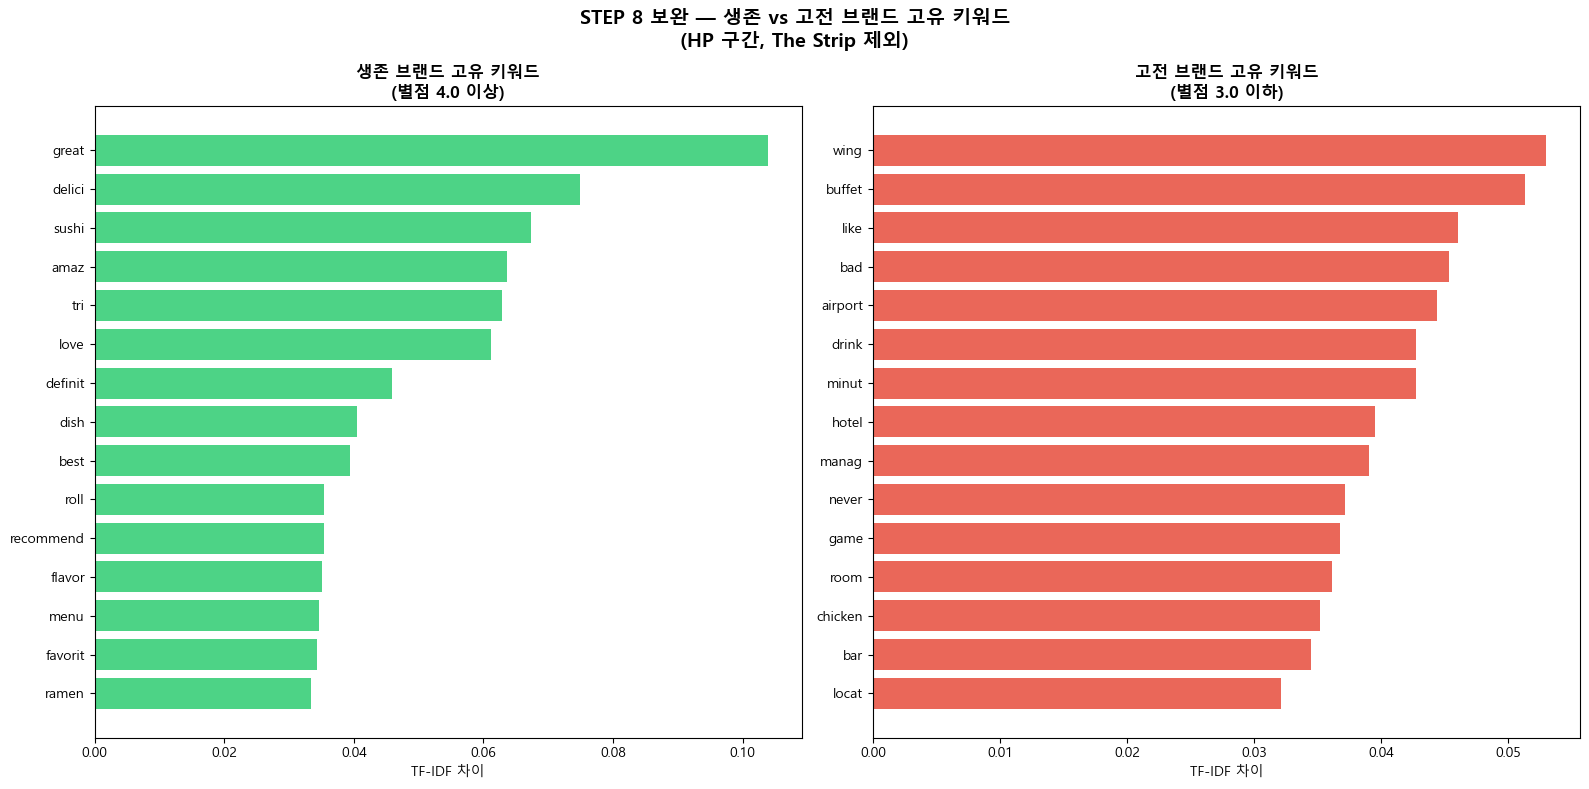

저장 완료: step8_survival_no_strip.png


In [32]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('STEP 8 보완 — 생존 vs 고전 브랜드 고유 키워드\n(HP 구간, The Strip 제외)',
             fontsize=14, fontweight='bold')

top_s_ns = survivor_diff_ns.head(15)
axes[0].barh(top_s_ns.index[::-1], top_s_ns.values[::-1],
             color='#2ecc71', alpha=0.85)
axes[0].set_title('생존 브랜드 고유 키워드\n(별점 4.0 이상)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('TF-IDF 차이')

top_str_ns = struggle_diff_ns.head(15)
axes[1].barh(top_str_ns.index[::-1], top_str_ns.values[::-1],
             color='#e74c3c', alpha=0.85)
axes[1].set_title('고전 브랜드 고유 키워드\n(별점 3.0 이하)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('TF-IDF 차이')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step8_survival_no_strip.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step8_survival_no_strip.png")

---
### STEP 8 보완 결과 — The Strip 제외 재분석

**분석 대상**
- 생존 브랜드: 429개 / 리뷰 114,265개
- 고전 브랜드: 204개 / 리뷰 17,805개

**생존 브랜드 고유 키워드 (Strip 제외)**:
great, delici, sushi, amaz, love, dish, roll, recommend, flavor, ramen, fresh, noodle, spicy

→ 음식 품질(delici, flavor, fresh) + **아시안 퀴진 전문성(sushi, roll, ramen, noodle)**
   고압력 환경에서 특색있는 전문 음식으로 차별화한 브랜드가 생존한다.

**고전 브랜드 고유 키워드 (Strip 제외)**:
wing, buffet, bad, airport, drink, minut, hotel, manag, never, game, room, waitress

→ 부속 시설 특성(hotel, airport, game, room) + **서비스 실패 신호(bad, never, minut, waitress, manag)**
   Strip 노이즈 제거 후 고전 브랜드의 핵심 문제가 서비스 품질임이 선명하게 드러났다.

---

### Strip 제외 전후 비교

| | Strip 포함 | Strip 제외 |
|---|---|---|
| 고전 브랜드 주요 특성 | 카지노/호텔 부속 시설 | 서비스 실패 + 부속 시설 |
| 새로 드러난 인사이트 | - | bad, never, minut, waitress → 서비스 품질 문제 |

The Strip 상권 노이즈를 제거하면 고전 브랜드의 핵심 문제가
**카지노/호텔 부속 특성**에서 **서비스 품질 실패**로 전환된다.

---

### STEP 8 최종 핵심 결론

> **고압력(HP) 환경에서 살아남는 독립 브랜드의 두 가지 조건:**
>
> 1. **음식 전문성**: delici, sushi, ramen, noodle, flavor, fresh
>    → 프랜차이즈가 제공하기 어려운 특색있는 전문 음식으로 차별화
>
> 2. **서비스 품질**: recommend, excel, perfect
>    → 부정적 서비스 경험(bad, minut, waitress, never)을 피하고
>    긍정적 경험을 제공하는 것이 생존의 핵심

> **실무 시사점**:
> 프랜차이즈 밀집 지역에서 독립 브랜드가 살아남으려면
> "프랜차이즈가 잘하는 것(빠른 서비스, 표준화)"을 따라하는 것이 아니라
> "프랜차이즈가 못하는 것(전문 음식, 개인화된 서비스 경험)"으로
> 차별화해야 한다.

> **분석 한계**:
> - The Strip 제외 후 고전 브랜드 리뷰(17,805개)가 생존 브랜드(114,265개) 대비
>   적어 키워드 신뢰도 차이가 있을 수 있음
> - Restaurants 카테고리 전체 분석으로 세부 업종 이질성 존재
> - 라스베가스 특유의 카지노/공항 상권 특성이 결과에 영향을 미칠 수 있어
>   타 도시에 대한 일반화에는 한계가 있음

"고압력 환경에서 독립 브랜드가 고전하는 원인은 두 가지로 구분된다.
첫째, 라스베가스 The Strip처럼 카지노/호텔 밀집 상권에서는
독립 레스토랑이 부속 시설로 인식되어 음식 품질과 무관하게 낮은 별점을 받는다.
둘째, 상권 요인을 통제했을 때 서비스 품질 실패(bad, minut, waitress)가
고전의 핵심 원인으로 드러난다."

---
## FPI 지도 시각화 — 창업자 입지 선정 도구

Las Vegas 독립 브랜드의 FPI 분포를 지도에 시각화한다.
창업자가 상권 진입 전 경쟁 압력 수준을 사전 파악할 수 있는 실무 활용 도구다.

- **색깔**: FPI 수치 (초록 → 낮은 압력 / 빨강 → 높은 압력)
- **크기**: 리뷰수 (매장 규모)
- **hover**: 업체명, 별점, FPI, 구간

In [33]:
import plotly.express as px

indie_map = indie_groups.copy()
indie_map['fpi_group'] = indie_map['fpi_group'].fillna('NP')

# FPI 구간 한글 라벨
group_label = {'NP': '무풍지대 (NP)', 'LP': '저압력 (LP)', 'HP': '고압력 (HP)'}
indie_map['구간'] = indie_map['fpi_group'].map(group_label)

fig = px.scatter_mapbox(
    indie_map,
    lat='latitude',
    lon='longitude',
    color='fpi_300m',
    color_continuous_scale='RdYlGn_r',
    size='review_count',
    size_max=20,
    hover_name='name',
    hover_data={
        'stars': True,
        'fpi_300m': ':.3f',
        '구간': True,
        'review_count': True,
        'neighborhood': True,
        'latitude': False,
        'longitude': False
    },
    zoom=11,
    height=700,
    title='Las Vegas 독립 브랜드 FPI 분포 지도 (fpi_300m 기준)'
)
fig.update_layout(
    mapbox_style='open-street-map',
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    coloraxis_colorbar=dict(
        title='FPI (경쟁압력)',
        tickvals=[0, 2, 4, 6, 8],
        ticktext=['0 (무풍)', '2', '4', '6', '8↑ (고압력)']
    )
)
fig.write_html(f"{PATH_to_save}/fpi_map.html")
print("저장 완료: fpi_map.html")
fig.show()

저장 완료: fpi_map.html


In [34]:
# FPI 구간별 색깔 지도 (NP/LP/HP 구분)
color_map = {
    '무풍지대 (NP)': '#4a90e2',
    '저압력 (LP)':   '#f5a623',
    '고압력 (HP)':   '#e65100'
}

fig2 = px.scatter_mapbox(
    indie_map,
    lat='latitude',
    lon='longitude',
    color='구간',
    color_discrete_map=color_map,
    size='review_count',
    size_max=20,
    hover_name='name',
    hover_data={
        'stars': True,
        'fpi_300m': ':.3f',
        '구간': True,
        'review_count': True,
        'neighborhood': True,
        'latitude': False,
        'longitude': False
    },
    zoom=11,
    height=700,
    title='Las Vegas 독립 브랜드 FPI 구간 분포 지도'
)
fig2.update_layout(
    mapbox_style='open-street-map',
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0}
)
fig2.write_html(f"{PATH_to_save}/fpi_map_group.html")
print("저장 완료: fpi_map_group.html")
fig2.show()

저장 완료: fpi_map_group.html
